In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

2026-02-23 19:02:00.061696: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 19:02:00.109069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 19:02:03.436349: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 19:02:11.172541: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
def main():
    model=model_gen()
    x,y=data_gen()
    trainx,trainy,valx,valy,testx,testy=split(x,y)
    history=model.fit(trainx,trainy,validation_data=(valx,valy),epochs=2,batch_size=32,verbose=1)
    test_loss=model.evaluate(testx,testy,verbose=1)
    display(history,test_loss)
    x_new=np.array([[7]],dtype=np.float32)

    y_pred = model.predict(testx) 
    show(testx,testy,y_pred)

    prediction=model.predict(x_new)
    print(f"the output is {prediction}")


In [3]:
def show(testX,testY,y_pred):
     
     plt.figure(figsize=(8,5)) 
     plt.scatter(testX, testY, label='Original y', color='blue', alpha=0.6) 
     plt.scatter(testX, y_pred, label='Predicted y', color='red', alpha=0.6) 
     plt.title('Original vs Predicted values') 
     plt.xlabel('x') 
     plt.ylabel('y') 
     plt.legend() 
     plt.show()

In [4]:
def display(history,test_loss):
    print(f"Test MSE: {test_loss:.4f}")
    # Plot training & validation loss
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

In [5]:
def model_gen():
    inputs=Input((1,))
    l1=Dense(512,activation='relu',name='layer1')(inputs)
    l2=Dense(1024,activation='relu',name='layer2')(l1)
    l3=Dense(512,activation='relu',name='layer3')(l2)
    outputs=Dense(1,activation='relu',name='output')(l3)
    model=Model(inputs,outputs)
    model.compile(optimizer=Adam(0.01),loss='mse')
    return model

In [6]:
def split(x,y,train=0.8,val=0.1,test=0.1):
    n=len(x)
    train_n=int(n*train)
    val_n=int(n*val)
    trainx,trainy=x[0:train_n],y[0:train_n]
    valx,valy=x[train_n:train_n+val_n],y[train_n:train_n+val_n]
    testx,testy=x[:train_n+val_n],y[:train_n+val_n]
    return trainx,trainy,valx,valy,testx,testy

In [7]:
def data_gen(cnt=500):
    x=np.random.randint(-10,10,50)
    y=fun(x)
    return x.reshape(-1,1),y

In [8]:
def fun(x):
    return 5*x+10

2026-02-23 19:02:19.789034: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - loss: 802.5984 - val_loss: 855.0000
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 801.8750 - val_loss: 855.0000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 807.7778
Test MSE: 807.7778


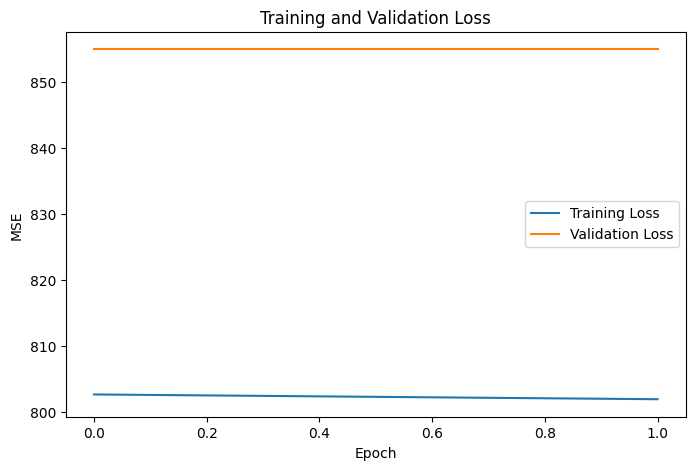

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


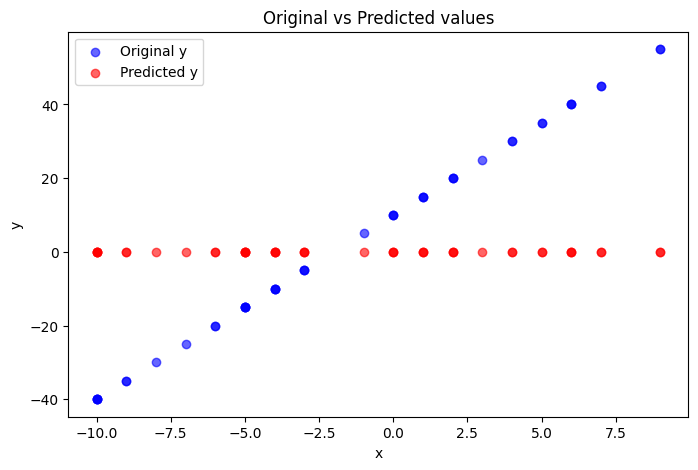

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
the output is [[0.]]


In [9]:
if __name__=="__main__":
    main()